In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [13]:
metrics_df = pd.read_json("metrics_diff.json")
metrics_df["engine"] = metrics_df['model'].apply(lambda x: "vLLM" if "nvidia/Llama-3.1-8B-Instruct-NVFP4" in x else "Ollama")
metrics_df["concurrency"] = metrics_df["concurrency"].astype(int)
metrics_df["requests_per_sec"] = metrics_df["requests_per_sec"].astype(int)
metrics_df["model"] = metrics_df["model"].replace("meta-llama/Llama-3.1-8B", "Meta LLaMA 3.1 8B").replace("nvidia/Llama-3.1-8B-Instruct-NVFP4", "NVIDIA LLaMA 3.1 8B")
metrics_df.head()

,timestamp,backend,model,url,dataset_split,requests,concurrency,requests_per_sec,tokens_per_sec,avg_latency_s,p50_latency_s,p95_latency_s,wall_time_s,engine
0,2026-05-09 11:28:53.711400747,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,1,0,173.621360,2.123377,2.348461,2.472014,2174.392593,vLLM
1,2026-05-09 11:48:55.275974989,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,2,0,338.983213,2.170231,2.386952,2.570673,1111.518170,vLLM
2,2026-05-09 11:59:50.985449076,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,4,1,648.539586,2.267460,2.470864,2.729842,581.640671,vLLM
3,2026-05-09 12:06:22.775961399,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,8,3,1199.099979,2.446920,2.652722,3.040690,314.403308,vLLM
4,2026-05-09 12:10:48.404856205,vllm,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,test_sft,1024,16,5,2054.918339,2.848370,3.065228,3.611848,183.550846,vLLM


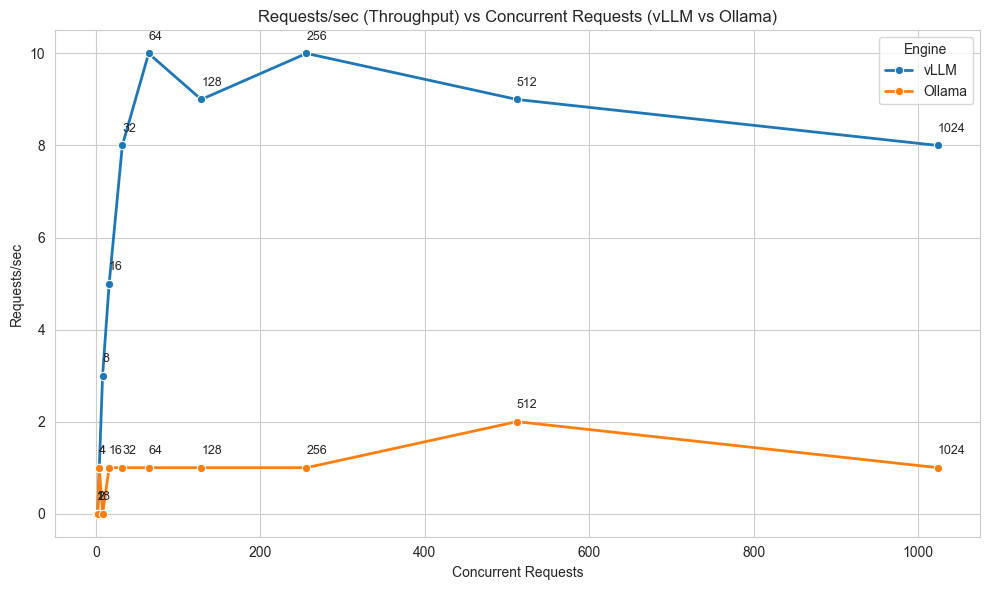

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="requests_per_sec",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Requests/sec (Throughput) vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Requests/sec")

for conc_req, rps in zip(metrics_df["concurrency"], metrics_df["requests_per_sec"]):
    ax.annotate(f"{conc_req}", (conc_req, rps), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()  

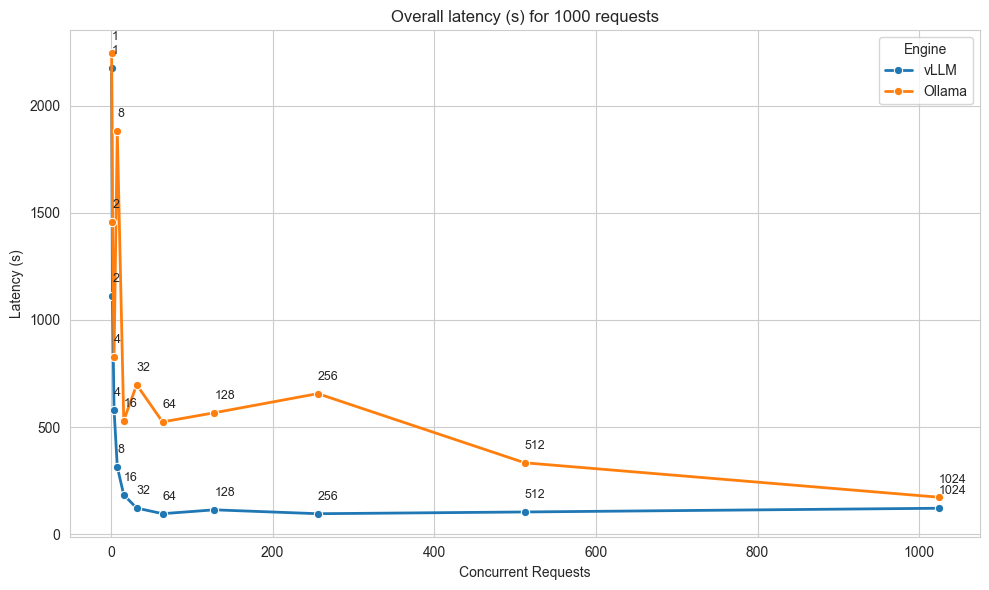

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="wall_time_s",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Overall latency (s) for 1000 requests")
plt.xlabel("Concurrent Requests")
plt.ylabel("Latency (s)")

for conc_req, latency in zip(metrics_df["concurrency"], metrics_df["wall_time_s"]):
    ax.annotate(f"{conc_req}", (conc_req, latency), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()  

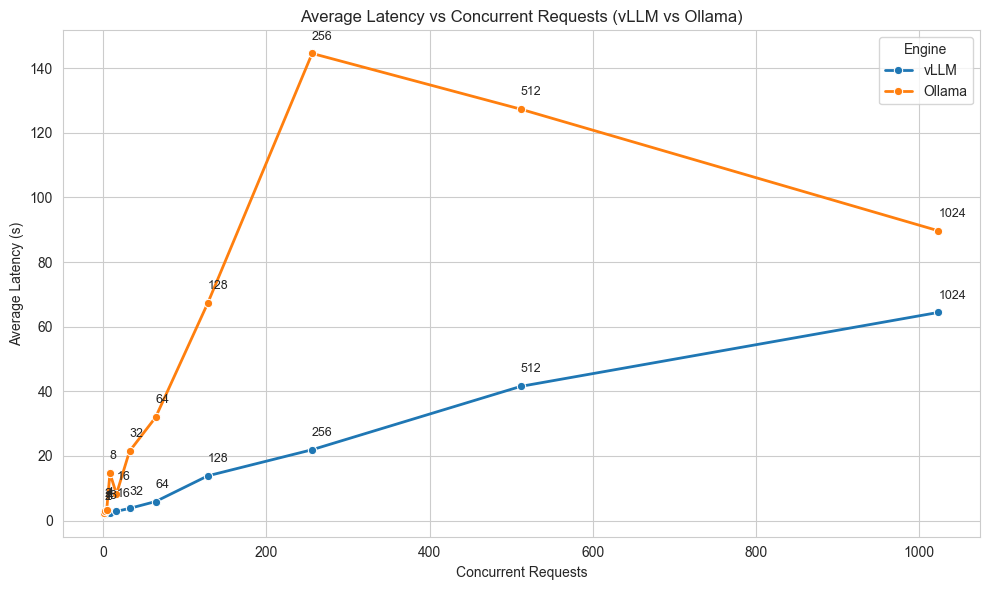

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="avg_latency_s",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Average Latency vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Average Latency (s)")

for conc_req, latency in zip(metrics_df["concurrency"], metrics_df["avg_latency_s"]):
    ax.annotate(f"{conc_req}", (conc_req, latency), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

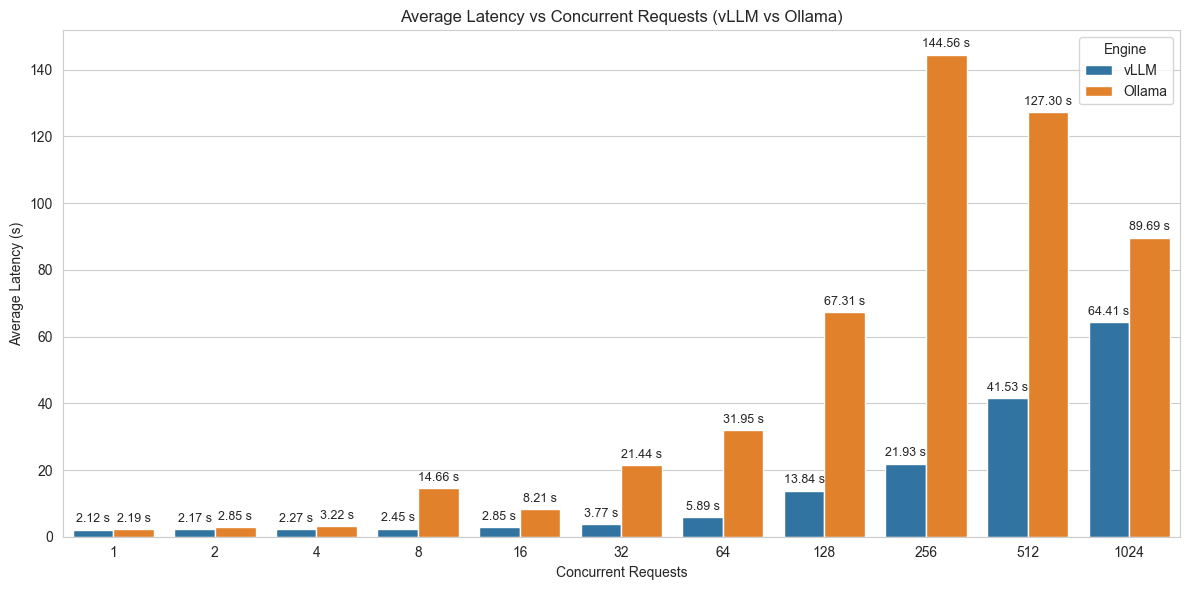

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="avg_latency_s",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f s",
        padding=3,
        fontsize=9
    )

plt.title("Average Latency vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Average Latency (s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

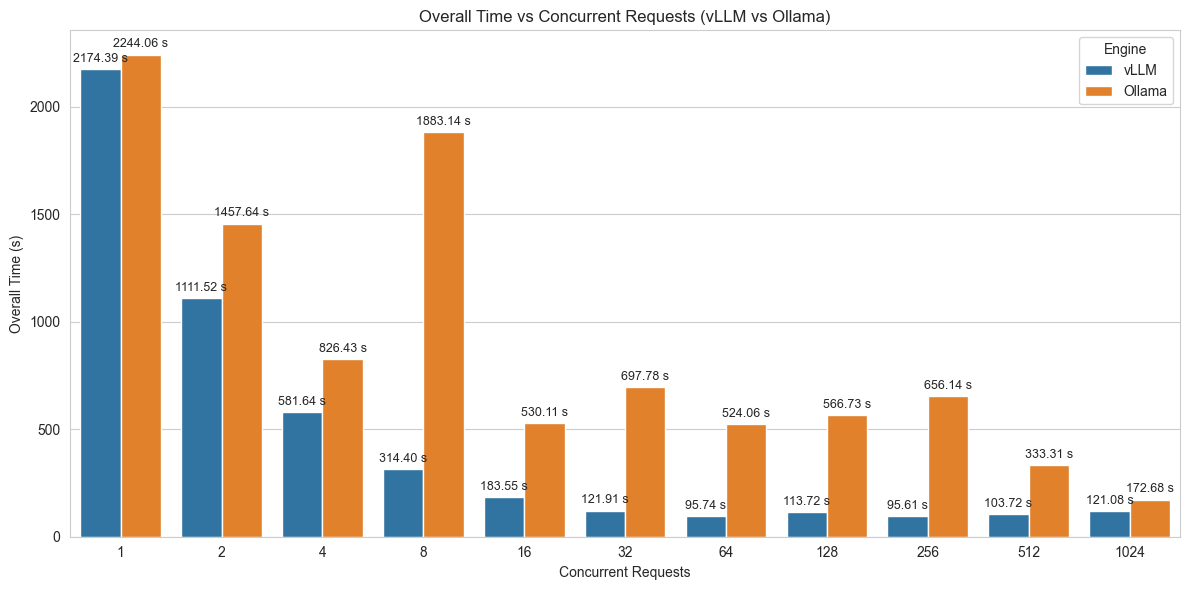

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="wall_time_s",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f s",
        padding=3,
        fontsize=9
    )

plt.title("Overall Time vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Overall Time (s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

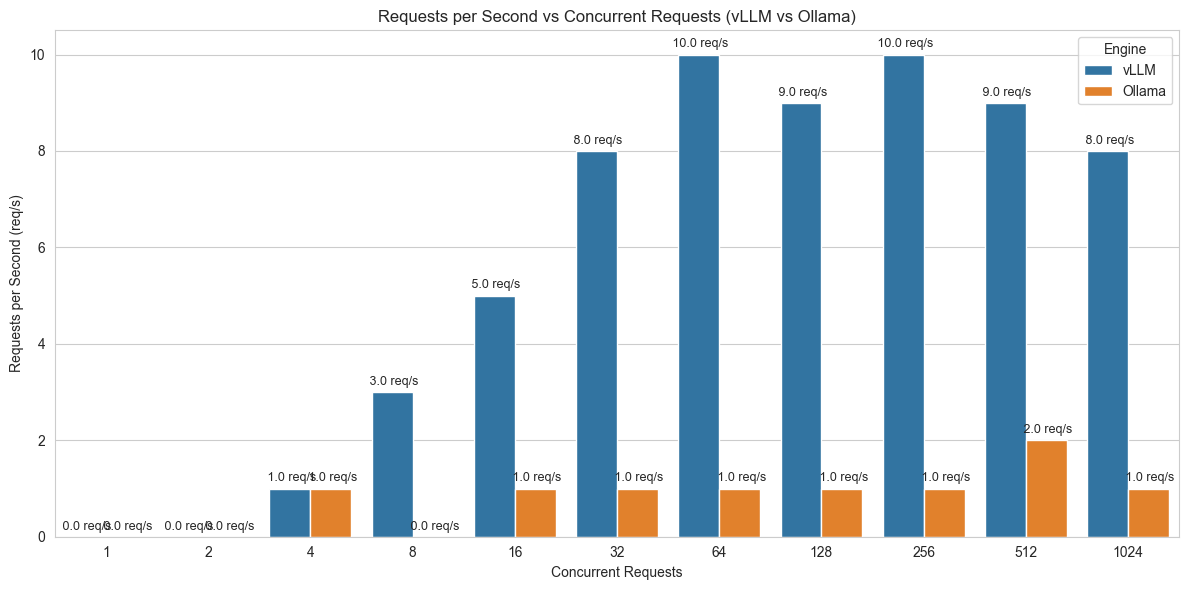

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrency"),
    x="concurrency",
    y="requests_per_sec",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=" %.1f req/s",
        padding=3,
        fontsize=9
    )

plt.title("Requests per Second vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Requests per Second (req/s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()